# **FREmu: Power Spectrum Emulator for f(R) Gravity**

**FREmu** is a neural-network-based emulator designed to predict the non-linear matter power spectrum in the Hu-Sawicki f(R) gravity model. It offers rapid and accurate forecasts across scales $0.0089 \, h \, \mathrm{Mpc}^{-1} < k < 0.5 \, h \, \mathrm{Mpc}^{-1}$ and redshifts $0 < z < 3$ .

### Key Features

* **Set cosmological parameters**
* **Retrieve power spectra**
* **Compute boost factors**
* **Estimate errors**

### Technical Overview

FREmu employs Principal Component Analysis (PCA) and Artificial Neural Networks (ANNs) to map cosmological parameters to power spectra. It is trained on data from the Quijote-MG simulation suite, encompassing a 7-dimensional parameter space:

* \$\Omega\_m\$ (matter density fraction): \$0.1 \leq \Omega\_m \leq 0.5\$
* \$\Omega\_b\$ (baryon density fraction): \$0.03 \leq \Omega\_b \leq 0.07\$
* \$h\$ (Hubble constant): \$0.5 \leq h \leq 0.9\$
* \$n\_s\$ (scalar spectral index): \$0.8 \leq n\_s \leq 1.2\$
* \$\sigma\_8\$ (amplitude of matter fluctuations): \$0.6 \leq \sigma\_8 \leq 1.0\$
* \$M\_{\nu}\$ (neutrino mass): \$0.01,\text{eV} \leq M\_{\nu} \leq 1.0,\text{eV}\$
* \$f\_{R\_0}\$ (f(R) gravity parameter):

$$
-3 \times 10^{-4} \leq f_{R_0} \leq 0
$$

The emulator achieves over 95% accuracy in most cases, making it a valuable tool for cosmological parameter inference .

### Access & Documentation

* GitHub Repository: [https://github.com/AstroBai/FREmu](https://github.com/AstroBai/FREmu)
* Research Paper: [FREmu: Power Spectrum Emulator for f(R) Gravity](https://iopscience.iop.org/article/10.3847/1538-4357/ad55ef)

---

- # **Installation**

In [ ]:
pip install -q fremu

- # **Initialize the FREmu emulator**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
from fremu import fremu

# Initialize the emulator
emu = fremu.emulator()

- # **Get the wavenumbers used in the emulator**

In [38]:
k_values = emu.get_k_values()
print("Supported k values (via get_k_values):")
print(k_values)
print("k range: [{:.2e}, {:.2e}] h/Mpc".format(k_values.min(), k_values.max()))
print("Number of k samples:", len(k_values))

# Save k values as a NumPy file
np.save('k_values.npy', k_values)

print("k_values saved as 'k_values.npy'")

Supported k values (via get_k_values):
[0.02783661 0.034351   0.04047887 0.04676717 0.05308225 0.05945362
 0.06576225 0.07196633 0.07827861 0.08470399 0.09096855 0.0972079
 0.1034763  0.10975764 0.11605431 0.12236697 0.12868173 0.13495008
 0.14119496 0.14751336 0.15378651 0.16006575 0.16639912 0.17271956
 0.17897652 0.18523537 0.19148068 0.19778899 0.20409377 0.21039393
 0.21669097 0.22297003 0.229262   0.23551415 0.24179106 0.24808565
 0.25434923 0.26063343 0.26692574 0.27324233 0.27955297 0.28583663
 0.29208763 0.29834498 0.30463826 0.31092791 0.31721682 0.32351876
 0.32981682 0.33611764 0.34237004 0.34864782 0.35494116 0.36119169
 0.36747671 0.37376478 0.3800654  0.38635399 0.39261402 0.39892645
 0.40520732 0.41149165 0.41778143 0.42404006 0.43034257 0.43663586
 0.44289962 0.44916344 0.45544141 0.46176345 0.46806442 0.47434852
 0.48063561 0.48690193 0.49316971 0.49945067 0.50571591 0.5119924
 0.51831261 0.52460896 0.53087573 0.53715735 0.54345796 0.54974307
 0.55599374 0.56228547 0.

- # **k-values **visualization and analysis****

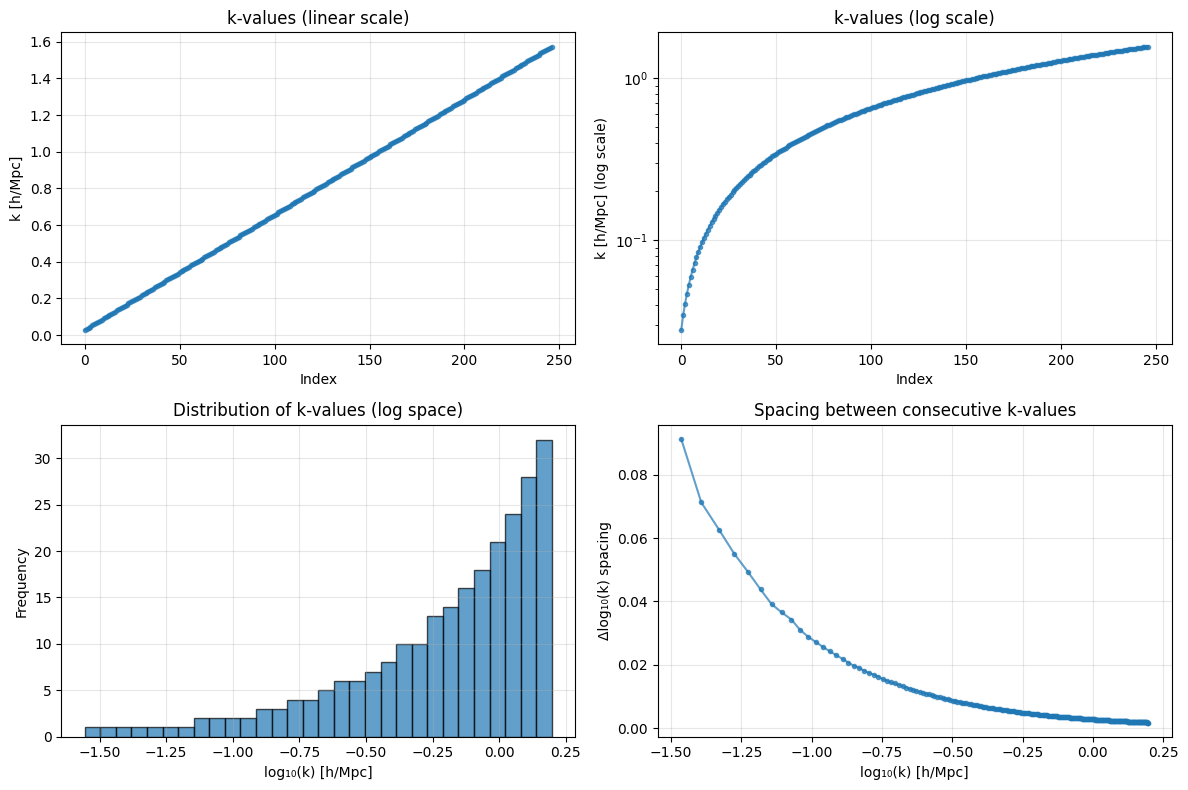

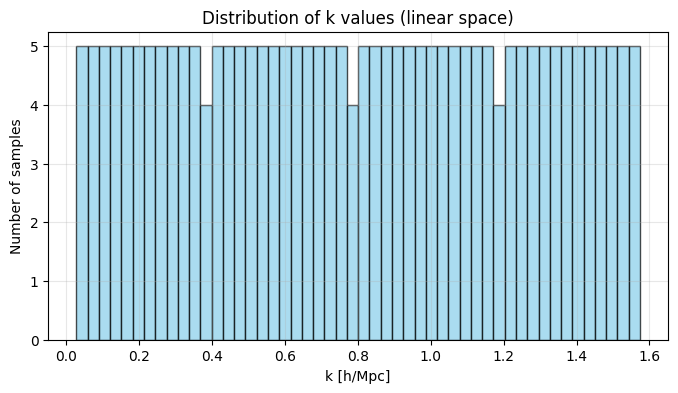

In [36]:
# Visualization - Comprehensive analysis
plt.figure(figsize=(12, 8))

# Linear scale
plt.subplot(2, 2, 1)
plt.plot(k_values, 'o-', markersize=3, alpha=0.7)
plt.xlabel('Index')
plt.ylabel('k [h/Mpc]')
plt.title('k-values (linear scale)')
plt.grid(True, alpha=0.3)

# Log scale
plt.subplot(2, 2, 2)
plt.semilogy(k_values, 'o-', markersize=3, alpha=0.7)
plt.xlabel('Index')
plt.ylabel('k [h/Mpc] (log scale)')
plt.title('k-values (log scale)')
plt.grid(True, alpha=0.3)

# Distribution histogram (log space)
plt.subplot(2, 2, 3)
plt.hist(np.log10(k_values), bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('log₁₀(k) [h/Mpc]')
plt.ylabel('Frequency')
plt.title('Distribution of k-values (log space)')
plt.grid(True, alpha=0.3)

# Spacing between consecutive k-values
plt.subplot(2, 2, 4)
k_spacing = np.diff(np.log10(k_values))
plt.plot(np.log10(k_values[1:]), k_spacing, 'o-', markersize=3, alpha=0.7)
plt.xlabel('log₁₀(k) [h/Mpc]')
plt.ylabel('Δlog₁₀(k) spacing')
plt.title('Spacing between consecutive k-values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram to see distribution
plt.figure(figsize=(8,4))
plt.hist(k_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('k [h/Mpc]')
plt.ylabel('Number of samples')
plt.title('Distribution of k values (linear space)')
plt.grid(True, alpha=0.3)
plt.show()

- # **k-values **statistics and spacing****

In [37]:
# Additional statistics
print("\nAdditional statistics:")
print(f"Minimum k: {k_values.min():.2e} h/Mpc")
print(f"Maximum k: {k_values.max():.2e} h/Mpc")
print(f"Mean k: {k_values.mean():.2e} h/Mpc")
print(f"Median k: {np.median(k_values):.2e} h/Mpc")
print(f"Number of k points: {len(k_values)}")
print(f"Log spacing range: [{k_spacing.min():.3f}, {k_spacing.max():.3f}]")

# Check if k-values are logarithmically spaced
mean_spacing = np.mean(k_spacing)
std_spacing = np.std(k_spacing)
print(f"\nSpacing analysis:")
print(f"Mean log spacing: {mean_spacing:.4f}")
print(f"Spacing std dev: {std_spacing:.4f}")
if std_spacing/mean_spacing < 0.1:
    print("k-values appear to be approximately logarithmically spaced")
else:
    print("k-values are not uniformly spaced in log space")

# Additional distribution statistics
print(f"\nDistribution statistics:")
print(f"Standard deviation: {k_values.std():.2e} h/Mpc")
print(f"25th percentile: {np.percentile(k_values, 25):.2e} h/Mpc")
print(f"75th percentile: {np.percentile(k_values, 75):.2e} h/Mpc")


Additional statistics:
Minimum k: 2.78e-02 h/Mpc
Maximum k: 1.57e+00 h/Mpc
Mean k: 8.01e-01 h/Mpc
Median k: 8.01e-01 h/Mpc
Number of k points: 247
Log spacing range: [0.002, 0.091]

Spacing analysis:
Mean log spacing: 0.0071
Spacing std dev: 0.0110
k-values are not uniformly spaced in log space

Distribution statistics:
Standard deviation: 4.48e-01 h/Mpc
25th percentile: 4.15e-01 h/Mpc
75th percentile: 1.19e+00 h/Mpc
